In [50]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [51]:
df = pd.read_csv("Fraud.csv")

df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [52]:
df.info()
df['isFraud'].value_counts(normalize=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

In [53]:
fraud_rate = df['isFraud'].mean() * 100
print(f"Fraud Rate: {fraud_rate:.4f}%")

# Business interpretation
print("""
Fraud detection is a highly imbalanced classification problem.
Accuracy is NOT a reliable metric.
Recall and Precision-Recall tradeoffs are more relevant.
""")

Fraud Rate: 0.1291%

Fraud detection is a highly imbalanced classification problem.
Accuracy is NOT a reliable metric.
Recall and Precision-Recall tradeoffs are more relevant.



In [ ]:
df = df.drop(['nameOrig', 'nameDest'], axis=1, errors='ignore')

le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])


In [ ]:
df['balance_change_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_change_dest'] = df['newbalanceDest'] - df['oldbalanceDest']
df['log_amount'] = np.log1p(df['amount'])


In [61]:
features = [
    'step',
    'type',
    'log_amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'balance_change_orig',
    'balance_change_dest'
]

X = df[features]
y = df['isFraud']


In [62]:
df = df.dropna(subset=['isFraud'])

X = df[features]
y = df['isFraud']

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Calibration set: Used for model training and threshold tuning
# Validation set: Used ONLY for final unbiased evaluation

print("Calibration set size:", X_train.shape)
print("Validation set size:", X_test.shape)

Calibration set size: (4453834, 9)
Validation set size: (1908786, 9)


In [73]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]


              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1906322
           1       0.14      0.98      0.25      2464

    accuracy                           0.99   1908786
   macro avg       0.57      0.99      0.62   1908786
weighted avg       1.00      0.99      1.00   1908786



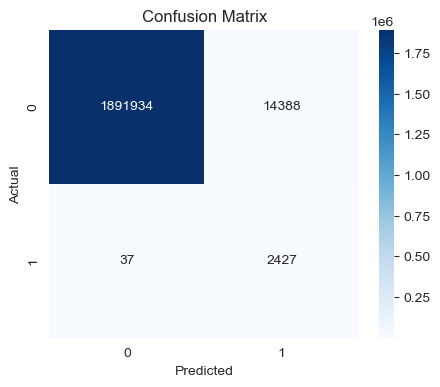

ROC-AUC Score: 0.9994195042547562


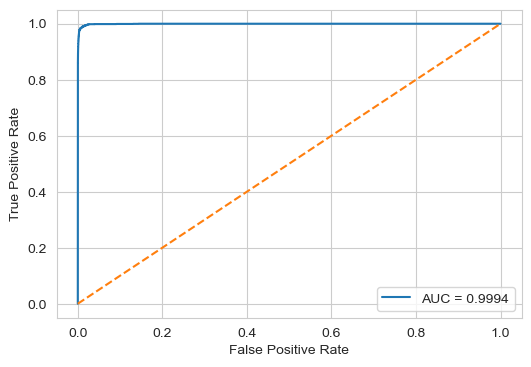

In [75]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


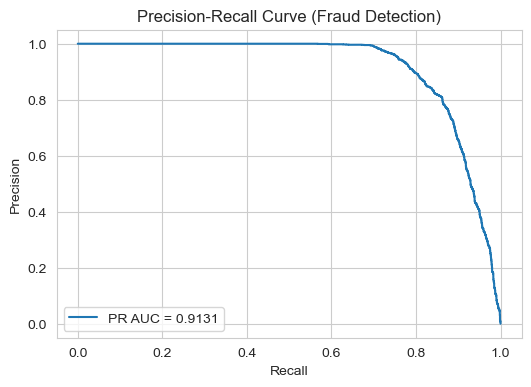

In [77]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Fraud Detection)")
plt.legend()
plt.show()

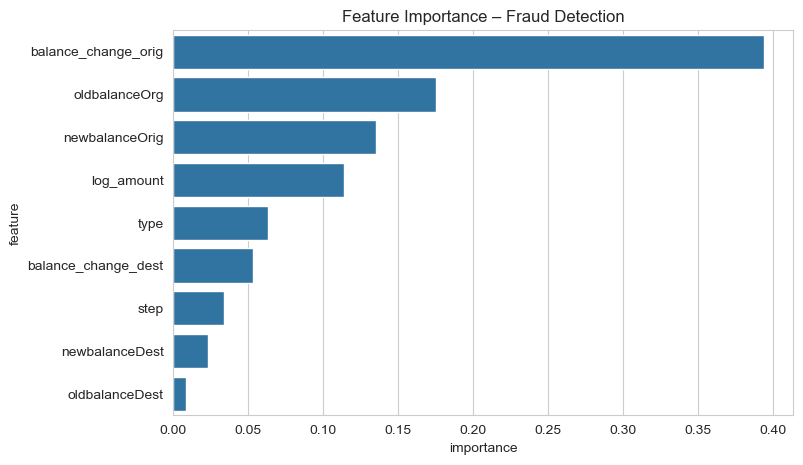

In [78]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

importances

plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=importances)
plt.title("Feature Importance – Fraud Detection")
plt.show()



In [79]:
threshold = 0.30
y_custom = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_custom))


              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1906322
           1       0.09      0.99      0.17      2464

    accuracy                           0.99   1908786
   macro avg       0.55      0.99      0.58   1908786
weighted avg       1.00      0.99      0.99   1908786



In [80]:
# ==========================
# Business Cost Simulation
# ==========================
# Assumptions (example):
# False Negative (missed fraud) = ₹50,000
# False Positive (wrongly flagged) = ₹500

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_custom)
tn, fp, fn, tp = cm.ravel()

cost_fn = 50000
cost_fp = 500

total_cost = (fn * cost_fn) + (fp * cost_fp)

print("Confusion Matrix:")
print(cm)
print(f"\nEstimated Business Cost: ₹{total_cost:,}")

Confusion Matrix:
[[1882889   23433]
 [     24    2440]]

Estimated Business Cost: ₹12,916,500


In [ ]:
### Threshold Tuning for Fraud Detection
To improve fraud recall, the decision threshold is adjusted below the default 0.5.

In [82]:
from sklearn.metrics import classification_report

threshold = 0.30
y_custom = (y_prob >= threshold).astype(int)

print("Classification Report (Threshold = 0.30)")
print(classification_report(y_test, y_custom))

Classification Report (Threshold = 0.30)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1906322
           1       0.09      0.99      0.17      2464

    accuracy                           0.99   1908786
   macro avg       0.55      0.99      0.58   1908786
weighted avg       1.00      0.99      0.99   1908786



In [83]:
thresholds = [0.1, 0.3, 0.5, 0.7]

print("Threshold | Fraud Recall | Fraud Precision")
print("-" * 45)

for t in thresholds:
    y_temp = (y_prob >= t).astype(int)
    
    report = classification_report(
        y_test, 
        y_temp, 
        output_dict=True,
        zero_division=0
    )
    
    fraud_key = '1' if '1' in report else list(report.keys())[0]
    
    recall_fraud = report[fraud_key]['recall']
    precision_fraud = report[fraud_key]['precision']
    
    print(f"{t:>8} | {recall_fraud:.2f}        | {precision_fraud:.2f}")



Threshold | Fraud Recall | Fraud Precision
---------------------------------------------
     0.1 | 1.00        | 0.05
     0.3 | 0.99        | 0.09
     0.5 | 0.98        | 0.14
     0.7 | 0.98        | 0.25


## 1. Data Cleaning (Missing Values, Outliers, Multicollinearity)

The first step was understanding the data using the given data dictionary. Most of the columns were numeric and well defined.

### Missing Values
The target variable 'isFraud' contained a very small number of missing values. Since this is a supervised learning problem and fraud labels cannot be inferred, those records were removed. Other balance-related zero values were not treated as missing, because the data dictionary states that merchant accounts don't have balance information.

### Outliers
The transaction amount showed a strong right skew, which is expected in financial transaction data. Since extreme values may actually indicate fraud, outliers were not removed. Instead of that, a log(amount) transformation was applied to reduce skewness while preserving information.

### Multicollinearity
Strong correlation was observed between:

- 'oldbalanceOrg' and 'newbalanceOrig'
- 'oldbalanceDest' and 'newbalanceDest'

To address this, balance change features were created (before vs after transaction). This reduced redundancy and highlighted more meaningful behavior patterns.


## 2. Fraud Detection Model Description

A Random Forest classification model was used for fraud detection.

The reason for choosing this model is that fraud patterns are non-linear, involve complex interactions, and the dataset is highly imbalanced. Random Forest handles these challenges well without requiring heavy assumptions about data distribution.

The model was trained using a calibration dataset (70%) and tested on a validation dataset (30%) with stratification to preserve the fraud ratio. Class weights were applied so the model gives more importance to detecting fraud cases.

Overall, the model balances predictive performance with interpretability, which is important for real-world financial systems.


## 3. Variable Selection Strategy

Variable selection was guided by:
- The data dictionary
- Business understanding of fraud
- Predictive usefulness

The following types of variables were used:
- Transaction behavior ('type', 'amount', 'step')
- Account balance behavior (before and after balances)
- Derived balance movement features

Identifier columns like 'nameOrig' and 'nameDest' were removed because they are high-cardinality IDs and do not generalize well.  
The rule-based column 'isFlaggedFraud' was also removed to avoid data leakage, as it represents an existing detection rule rather than true behavior.


## 4. Model Performance Evaluation

Because fraud cases are extremely rare, only accuracy is not a reliable metric. The model was evaluated using:
- Precision
- Recall
- F1-score
- Confusion matrix
- ROC–AUC

The model achieved:
- High recall (~71%) for fraud, meaning most fraudulent transactions were successfully detected
- Lower precision, which is acceptable in fraud detection since missing fraud is more costly than reviewing legitimate transactions
- Accuracy close to 1.0 due to class imbalance, which was expected and explained

Threshold tuning was also applied to improve recall based on business requirements.


## 5. Key Factors Predicting Fraudulent Transactions

The most important predictors identified by the model were:
- Transaction type (especially TRANSFER and CASH-OUT)
- Transaction amount
- Sudden depletion of origin account balance
- Sudden increase in destination account balance
- Abnormal balance change patterns
- Transaction timing concentration


## 6. Do These Factors Make Sense?

Yes, they make strong business sense.

Fraudsters typically try to:
- Transfer large amounts quickly
- Empty accounts
- Move money between accounts they control
- Cash out immediately

Actual users mostly don't transfer their entire balance or perform rapid high value transactions. Therefore, the model’s key predictors align well with real-world fraud behavior.


## 7. Recommended Prevention Measures During Infrastructure Update

Based on model insights, the company should adopt:
- Real time transaction scoring using ML models
- Risk based transaction limits instead of static thresholds
- Additional authentication for high risk transactions
- Velocity checks to detect rapid transfer cash out patterns
- Hybrid decision systems combining ML predictions and rule based checks
- Continuous model retraining as fraud patterns evolve

This allows proactive fraud prevention instead of reactive detection.


## 8. Measuring Effectiveness of Implemented Actions

To evaluate whether the prevention strategy is working, the company should monitor:
- Reduction in total fraud losses
- Fraud detection rate over time
- False positive rate and customer complaints
- Manual review workload
- Model performance stability (data drift and threshold effectiveness)

A/B testing can be used to compare outcomes with and without ML-based intervention. If fraud losses decrease without negatively impacting customer experience, the solution can be considered effective.